**Goal:** see what a maximum-margin boundary actually looks like -- curbs, support vectors and all --
then watch the kernel trick separate data no straight line can. Pairs with the concept note
[Support Vector Machines](l08_concept_svm.qmd).

> **Previously:** L07 -- Naive Bayes  |  **Next:** L09 -- The Bias-Variance Dilemma & Cross-Validation

> This page is the read-only view. To run the lab, open the notebook
> (`l08_lab_svm.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

Two jobs today. First, the coqui detector one last time: L04's logistic regression drew *a* line
through the calls -- now we draw the *widest-street* line and meet the handful of calls that hold it
up. Second, a genuinely nonlinear problem: two kayak-tour operators run interleaving nightly routes
through a bioluminescent bay, and stray GPS pings need to be attributed to the right operator -- no
straight line can do it.

Both datasets are **synthetic** (fixed seeds, identical numbers for everyone) with *fictionalized but
plausible* values.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second imports,
seeds the generator, and builds the data.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)          # the L02 generator, verbatim
n = 150                                  # calls per species

calls = pd.DataFrame({
    "co_khz":  np.concatenate([rng.normal(1.15, 0.18, n), rng.normal(1.45, 0.18, n)]),
    "qui_khz": np.concatenate([rng.normal(2.05, 0.25, n), rng.normal(2.45, 0.25, n)]),
    "species": ["coqui"] * n + ["portoricensis"] * n,
})

from sklearn.model_selection import train_test_split

X = calls[["co_khz", "qui_khz"]]
y = calls["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=11, stratify=y)
print(len(X_train), "training calls /", len(X_test), "test calls")

225 training calls / 75 test calls


~~~text
225 training calls / 75 test calls
~~~

Same seed, same split as L02 and L04 -- every accuracy below is directly comparable with L04's kNN
0.840 and logistic regression's 0.853.

## Step 1: The Widest Street Through the Coqui Calls

### Naive approach: any good line

L04's logistic regression, re-earned in one cell:

In [3]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train, y_train)
print(f"logistic test accuracy:   {logreg.score(X_test, y_test):.3f}")

logistic test accuracy:   0.853


~~~text
logistic test accuracy:   0.853
~~~

### Better approach: the line with the most breathing room

A linear SVM asks for more than separation -- it wants the boundary that keeps the widest possible
margin to both classes:

In [4]:
from sklearn.svm import SVC

svm_lin = SVC(kernel="linear").fit(X_train, y_train)
print(f"linear SVM test accuracy: {svm_lin.score(X_test, y_test):.3f}")
print(f"support vectors: {len(svm_lin.support_vectors_)} of {len(X_train)} training calls")

linear SVM test accuracy: 0.840
support vectors: 100 of 225 training calls


~~~text
linear SVM test accuracy: 0.840
support vectors: 100 of 225 training calls
~~~

Accuracy is in the same band as logistic (0.840 vs 0.853 -- on this easy, noisy data no linear method
dominates). The interesting part is the geometry. Draw both boundaries, plus the SVM's margin curbs
and the support vectors that hold them:

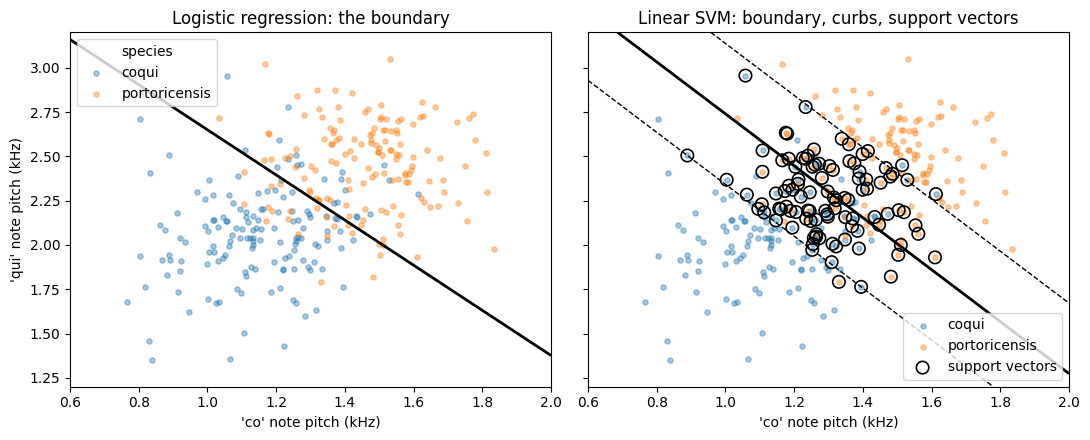

In [5]:
xx, yy = np.meshgrid(np.linspace(0.6, 2.0, 200), np.linspace(1.2, 3.2, 200))
grid = pd.DataFrame({"co_khz": xx.ravel(), "qui_khz": yy.ravel()})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, title in zip(axes, ["Logistic regression: the boundary",
                            "Linear SVM: boundary, curbs, support vectors"]):
    for name, group in calls.groupby("species"):
        ax.scatter(group["co_khz"], group["qui_khz"], label=name, alpha=0.4, s=14)
    ax.set_xlabel("'co' note pitch (kHz)")
    ax.set_title(title)

p_grid = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)
axes[0].contour(xx, yy, p_grid, levels=[0.5], colors="black", linewidths=2)
axes[0].set_ylabel("'qui' note pitch (kHz)")
axes[0].legend(title="species")

score_grid = svm_lin.decision_function(grid).reshape(xx.shape)
axes[1].contour(xx, yy, score_grid, levels=[-1, 0, 1], colors="black",
                linewidths=[1, 2, 1], linestyles=["--", "-", "--"])
axes[1].scatter(svm_lin.support_vectors_[:, 0], svm_lin.support_vectors_[:, 1],
                s=80, facecolors="none", edgecolors="black", linewidths=1.2,
                label="support vectors")
axes[1].legend()
plt.tight_layout()
plt.show()

Read the right panel like the concept note: the solid line is the boundary, the dashed lines are the
curbs of the street, and every circled call -- the support vectors -- either presses against a curb or
violates it. The other 125 training calls could be deleted and *nothing would move*. The two species
overlap, so a hard, violation-free street is impossible -- the soft margin is tolerating the calls
caught inside it.

## Step 2: When No Straight Line Works -- completion problem

The bioluminescent-bay pings. Operator `bahia_glow` hugs the inner crescent of the bay; `luna_azul`
sweeps the outer arc. The routes interleave:

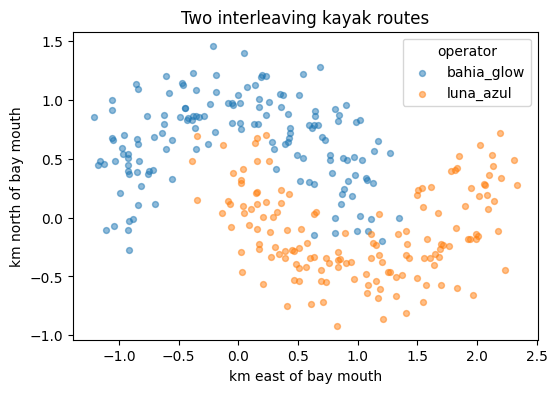

In [6]:
from sklearn.datasets import make_moons

raw_xy, raw_label = make_moons(n_samples=300, noise=0.2, random_state=11)
pings = pd.DataFrame(raw_xy.round(3), columns=["east_km", "north_km"])
pings["operator"] = np.where(raw_label == 0, "bahia_glow", "luna_azul")

Xp = pings[["east_km", "north_km"]]
yp = pings["operator"]
Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.25,
                                                        random_state=11, stratify=yp)

fig, ax = plt.subplots(figsize=(6, 4))
for name, group in pings.groupby("operator"):
    ax.scatter(group["east_km"], group["north_km"], label=name, alpha=0.5, s=18)
ax.set_xlabel("km east of bay mouth")
ax.set_ylabel("km north of bay mouth")
ax.legend(title="operator")
ax.set_title("Two interleaving kayak routes")
plt.show()

Two crescents, hooked into each other. Try a straight line, then let the RBF kernel lift the pings
into a space where a flat boundary *does* exist. Complete the marked lines:

In [7]:
# Uncomment and complete the marked lines:
# svm_moons_lin = SVC(kernel=____).fit(Xp_train, yp_train)     # a linear SVM
# print(f"linear SVM test accuracy: {svm_moons_lin.score(Xp_test, yp_test):.3f}")
# svm_moons_rbf = SVC(kernel=____).fit(Xp_train, yp_train)     # the RBF kernel
# print(f"RBF SVM test accuracy:    {svm_moons_rbf.score(Xp_test, yp_test):.3f}")

<details><summary>Expected Output</summary>

~~~text
linear SVM test accuracy: 0.800
RBF SVM test accuracy:    0.893
~~~

The straight line tops out at 0.800 -- it cannot bend, so it amputates the tips of both crescents. The
RBF kernel reaches 0.893 *with the same training data and the same SVC recipe*: only the kernel
changed, and with it the shape the boundary is allowed to take.
</details>

And the payoff, visualized. (This cell is self-contained -- it fits its own RBF model -- so it runs
even before you finish the cell above. Note the grid must span the *kayak* coordinates, not Step 1's
kilohertz ranges.)

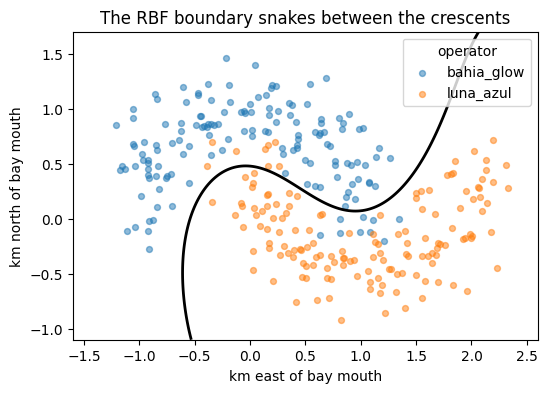

In [8]:
svm_rbf_demo = SVC(kernel="rbf").fit(Xp_train, yp_train)

mxx, myy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.1, 1.7, 200))
mgrid = pd.DataFrame({"east_km": mxx.ravel(), "north_km": myy.ravel()})
mscore = svm_rbf_demo.decision_function(mgrid).reshape(mxx.shape)

fig, ax = plt.subplots(figsize=(6, 4))
for name, group in pings.groupby("operator"):
    ax.scatter(group["east_km"], group["north_km"], label=name, alpha=0.5, s=18)
ax.contour(mxx, myy, mscore, levels=[0], colors="black", linewidths=2)
ax.set_xlabel("km east of bay mouth")
ax.set_ylabel("km north of bay mouth")
ax.legend(title="operator")
ax.set_title("The RBF boundary snakes between the crescents")
plt.show()

This is the concept note's promise made visible: in the lifted space the boundary is a flat
hyperplane, but projected back onto the bay map it bends around each crescent. No hand-designed curve
-- the kernel found this shape from dot products alone.

## Your Turn

### Exercise 1 -- The C dial

C sets how strictly margin violations are punished on the coqui data. For C = 0.1, 1, and 100, report
the test accuracy and the number of support vectors. What happens to the street as C grows?

**Hint:** loop over `(0.1, 1, 100)`, refit `SVC(kernel="linear", C=C)` on the coqui training calls, and print `model.score(X_test, y_test)` and `len(model.support_vectors_)`.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
C=0.1: test accuracy 0.853, support vectors 170
C=1: test accuracy 0.840, support vectors 100
C=100: test accuracy 0.867, support vectors 76
~~~

The accuracies barely move on this data -- but look at the support-vector counts: 170 to 100 to 76.
Low C buys a wide, tolerant street held up by most of the data; high C narrows the street until only
the most contested calls define it. On noisier data, cranking C is how an SVM starts memorizing noise
-- which is exactly what Exercise 2 catches in the act.
</details>

### Exercise 2 -- Catch the overfit

The RBF kernel has its own dial: `gamma`, the reach of each training point's influence. Fit the kayak
data with gamma = 1 and gamma = 100, and for each print *both* the training accuracy and the test
accuracy. Which model is better -- and by which number?

**Hint:** for `gamma` in `(1, 100)`, fit `SVC(kernel="rbf", gamma=gamma)` on the kayak training pings and print accuracy on the TRAINING set (`Xp_train, yp_train`) and on the TEST set (`Xp_test, yp_test`).

In [10]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
gamma=1: train 0.960  test 0.893
gamma=100: train 0.996  test 0.840
~~~

By training accuracy, gamma=100 looks superior: 0.996, nearly perfect. By test accuracy it is the
*worse* model: 0.840 vs 0.893. With gamma cranked up, each ping's influence shrinks to a tiny island
and the boundary wraps itself around individual training points -- memorizing them instead of learning
the crescents. The gap between a shining training score and a sagging test score is called
**overfitting**, and you have now seen it with your own eyes. Unit III is about catching and curing it
systematically.
</details>

## Summary

- A linear SVM scored in the same band as logistic regression on the coqui calls (0.840 vs 0.853) --
  but only 100 of 225 training calls (the support vectors) actually hold its boundary in place.
- C is the strictness dial: low C means a wide, tolerant street held by many calls; high C means a
  narrow street held by few -- and, on noisy data, a step toward memorization.
- The kernel trick changed nothing but the kernel and lifted the kayak accuracy from 0.800 (linear) to
  0.893 (RBF) -- a flat boundary in a lifted space is a curved one back on the map.
- gamma=100 won on training (0.996) and lost on test (0.840): your first named sighting of
  overfitting. Unit III makes a science of it.
- This closes Unit II's algorithm roster: linear regression, logistic regression, the Perceptron,
  GDA/LDA, Naive Bayes, and SVM. Next (L09): learning theory -- the bias-variance dilemma and
  cross-validation, where overfitting stops being an anecdote and becomes a measurement.